# Time Series Assignment — Forecasting Exchange Rates

## Objective
The objective of this assignment is to forecast exchange rates using **Time Series Analysis**.

This notebook uses:

1. ARIMA model  
2. Exponential Smoothing model  

The dataset used is `exchange_rate.csv`.

The dataset contains:
- `date`: Date column
- `Ex_rate`: Exchange rate value

## 1. Install Required Libraries

In [6]:
# Run this cell only if libraries are missing
# !pip install pandas numpy matplotlib seaborn statsmodels scikit-learn

## 2. Import Required Libraries

In [7]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Time series libraries
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# Part 1: Data Preparation and Exploration

## 3. Load Dataset and Parse Date Column

In [8]:
df = pd.read_csv("exchange_rate.csv")

print("Dataset Shape:", df.shape)
display(df.head())
display(df.tail())

Dataset Shape: (7588, 2)


,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


,date,Ex_rate
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825
7587,10-10-2010 00:00,0.720825


In [9]:
# Convert date column to datetime format safely
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

# Check if any dates failed to convert
print("Invalid dates after conversion:", df["date"].isnull().sum())

# Drop rows where date conversion failed
df = df.dropna(subset=["date"])

# Sort data by date
df = df.sort_values("date")

# Set date as index
df.set_index("date", inplace=True)

print("Dataset after date parsing:")
display(df.head())

print("\nDataset Information:")
df.info()

Invalid dates after conversion: 0
Dataset after date parsing:


,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


## 4. Missing Values and Duplicate Check

In [10]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Dates:", df.index.duplicated().sum())

# Remove duplicate dates if present
df = df[~df.index.duplicated(keep="first")]

# Handle missing values using forward fill
df["Ex_rate"] = df["Ex_rate"].ffill()

print("\nMissing values after treatment:")
print(df.isnull().sum())

Missing Values:
Ex_rate    0
dtype: int64

Duplicate Dates: 0

Missing values after treatment:
Ex_rate    0
dtype: int64


## 5. Initial Time Series Plot

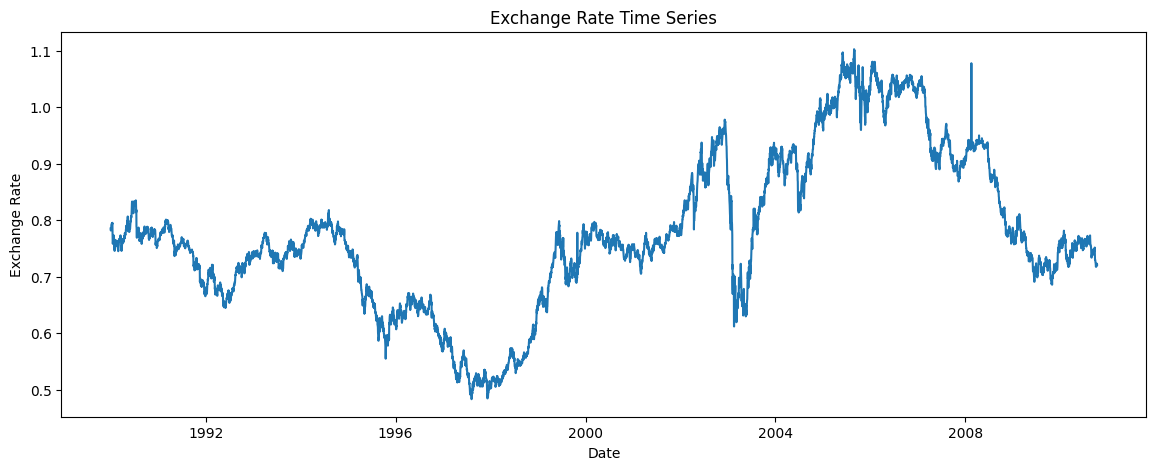

In [11]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df["Ex_rate"])
plt.title("Exchange Rate Time Series")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

## 6. Rolling Mean and Rolling Standard Deviation

Rolling statistics help us understand trend and variability over time.

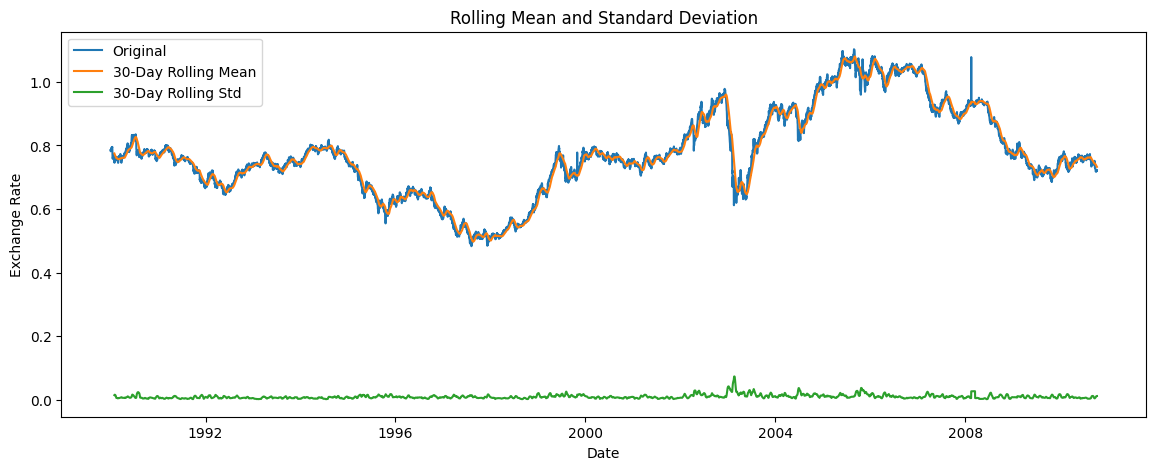

In [12]:
rolling_mean = df["Ex_rate"].rolling(window=30).mean()
rolling_std = df["Ex_rate"].rolling(window=30).std()

plt.figure(figsize=(14,5))
plt.plot(df["Ex_rate"], label="Original")
plt.plot(rolling_mean, label="30-Day Rolling Mean")
plt.plot(rolling_std, label="30-Day Rolling Std")
plt.title("Rolling Mean and Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

## 7. Stationarity Check using ADF Test

ARIMA works better when the series is stationary.

ADF Test Hypotheses:

- Null Hypothesis H0: Series is non-stationary.
- Alternative Hypothesis H1: Series is stationary.

If p-value < 0.05, we reject H0 and consider the series stationary.

In [13]:
def adf_test(series):
    result = adfuller(series.dropna())

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")

    for key, value in result[4].items():
        print(f"{key}: {value}")

    if result[1] < 0.05:
        print("\nConclusion: Series is stationary.")
    else:
        print("\nConclusion: Series is non-stationary.")

adf_test(df["Ex_rate"])

ADF Statistic: -1.6649941807381528
p-value: 0.4492327353597901
Critical Values:
1%: -3.4312123140180137
5%: -2.861921078147796
10%: -2.5669728434336108

Conclusion: Series is non-stationary.


## 8. Differencing the Series

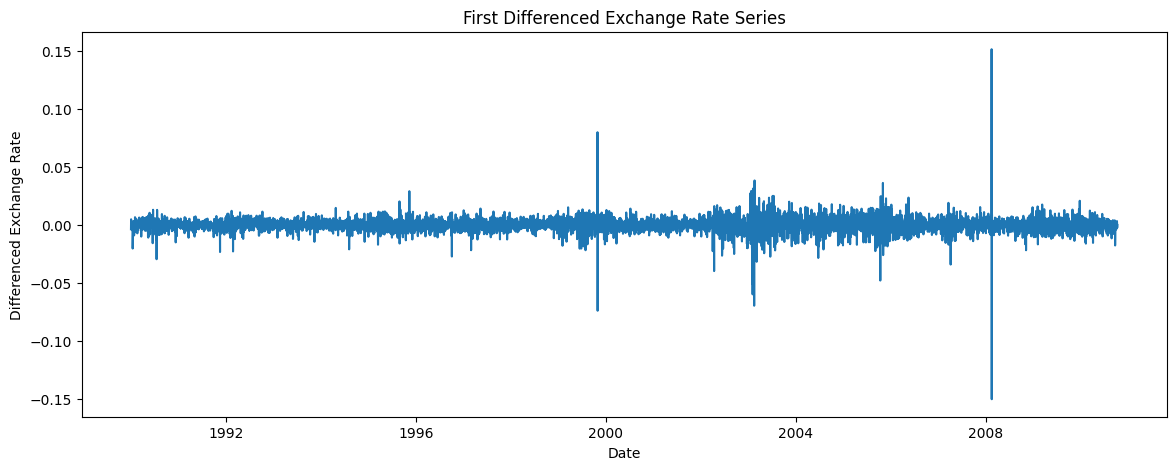

ADF Test after first differencing:
ADF Statistic: -99.39343120118629
p-value: 0.0
Critical Values:
1%: -3.4312123140180137
5%: -2.861921078147796
10%: -2.5669728434336108

Conclusion: Series is stationary.


In [14]:
df["Ex_rate_diff"] = df["Ex_rate"].diff()

plt.figure(figsize=(14,5))
plt.plot(df["Ex_rate_diff"])
plt.title("First Differenced Exchange Rate Series")
plt.xlabel("Date")
plt.ylabel("Differenced Exchange Rate")
plt.show()

print("ADF Test after first differencing:")
adf_test(df["Ex_rate_diff"].dropna())

# Part 2: Model Building — ARIMA

## 9. ACF and PACF Plots

ACF helps estimate `q`.

PACF helps estimate `p`.

Since first differencing is used, `d = 1`.

<Figure size 1200x400 with 0 Axes>

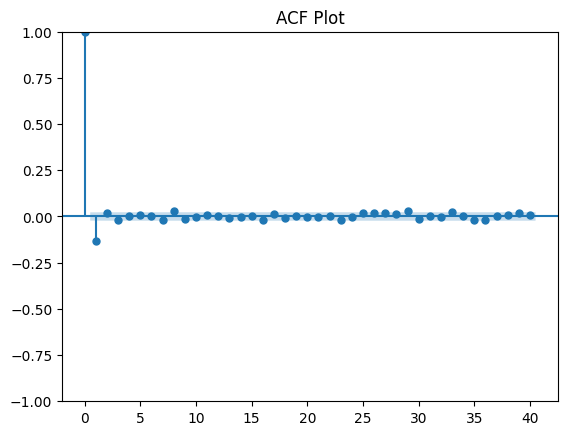

<Figure size 1200x400 with 0 Axes>

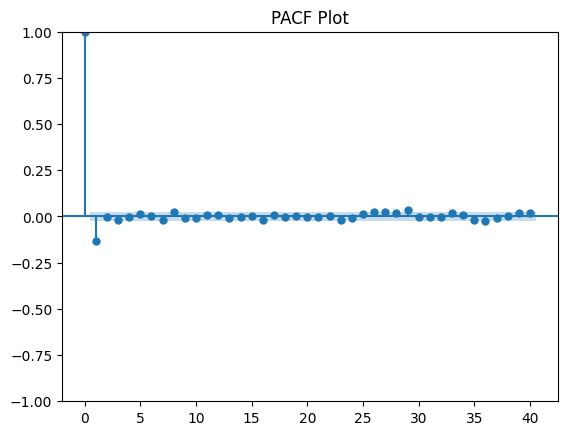

In [15]:
plt.figure(figsize=(12,4))
plot_acf(df["Ex_rate_diff"].dropna(), lags=40)
plt.title("ACF Plot")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df["Ex_rate_diff"].dropna(), lags=40, method="ywm")
plt.title("PACF Plot")
plt.show()

## 10. Train-Test Split for Time Series

For time series, we do not use random split.

We keep the last 20% data for testing.

Train Size: (6070,)
Test Size: (1518,)


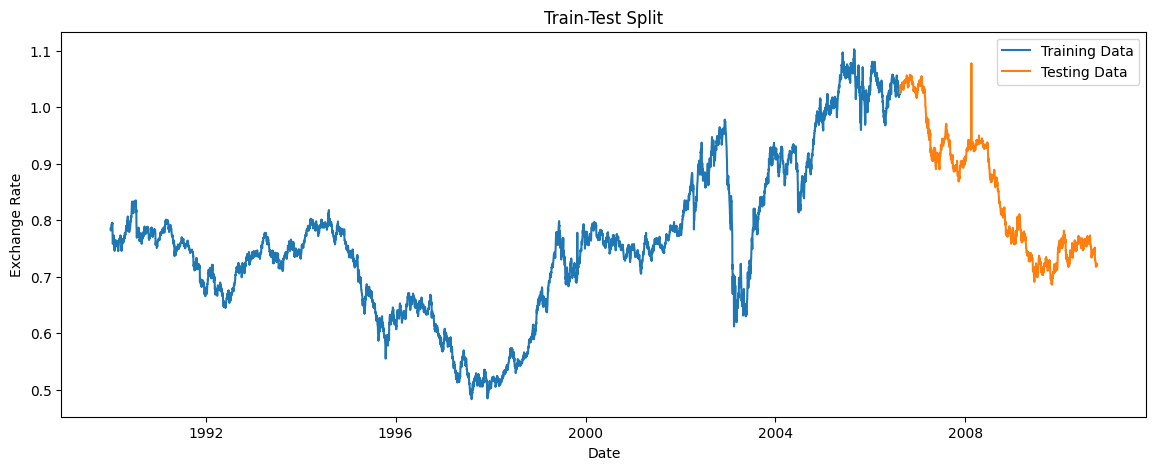

In [16]:
series = df["Ex_rate"]

train_size = int(len(series) * 0.80)

train = series.iloc[:train_size]
test = series.iloc[train_size:]

print("Train Size:", train.shape)
print("Test Size:", test.shape)

plt.figure(figsize=(14,5))
plt.plot(train, label="Training Data")
plt.plot(test, label="Testing Data")
plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

## 11. ARIMA Parameter Selection using AIC

We test different combinations of `(p, d, q)` and select the model with the lowest AIC.

Here, `d = 1` because first differencing is applied.

In [17]:
import itertools

p_values = range(0, 4)
d_values = [1]
q_values = range(0, 4)

best_aic = np.inf
best_order = None
best_model = None

for order in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()

        if model_fit.aic < best_aic:
            best_aic = model_fit.aic
            best_order = order
            best_model = model_fit

    except Exception as e:
        continue

print("Best ARIMA Order:", best_order)
print("Best AIC:", best_aic)

Best ARIMA Order: (2, 1, 3)
Best AIC: -45436.21807005952


## 12. Fit ARIMA Model

In [18]:
arima_model = ARIMA(train, order=best_order)
arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(2, 1, 3)   Log Likelihood               22724.109
Date:                Sat, 09 May 2026   AIC                         -45436.218
Time:                        15:16:15   BIC                         -45395.952
Sample:                    01-01-1990   HQIC                        -45422.243
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7246      0.094     -7.674      0.000      -0.910      -0.540
ar.L2         -0.7064      0.078     -9.035      0.000      -0.860      -0.553
ma.L1          0.6674      0.094      7.075      0.0

## 13. ARIMA Residual Diagnostics

Residuals should behave like random noise.

If residuals show strong patterns, the model may be inadequate.

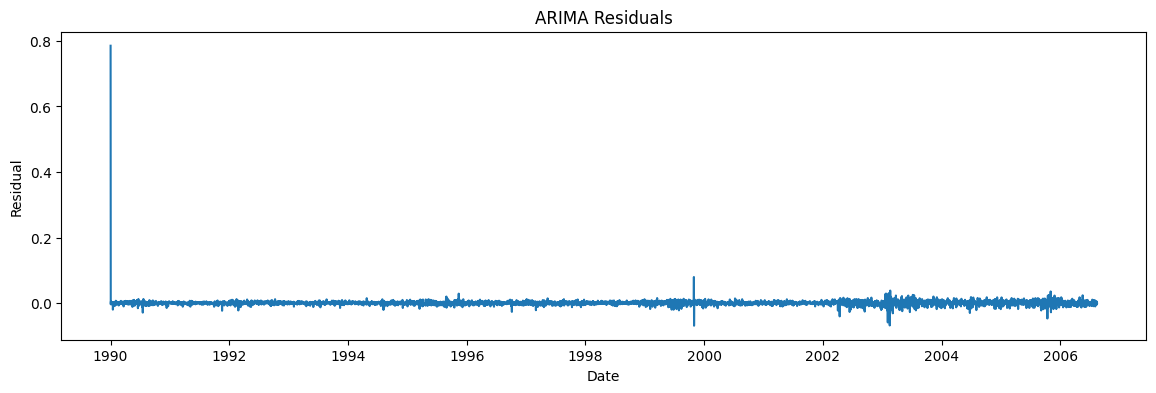

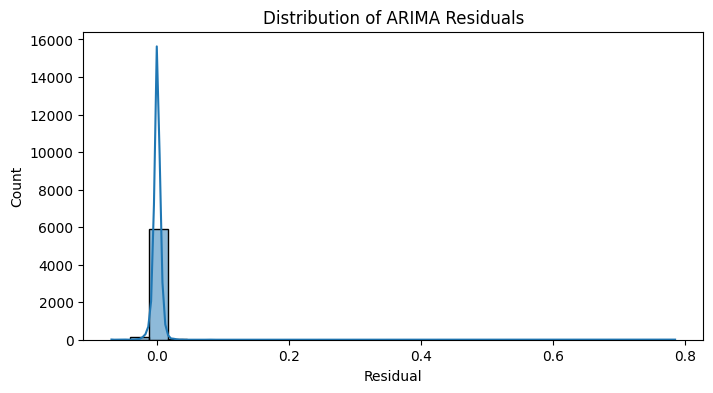

<Figure size 1200x400 with 0 Axes>

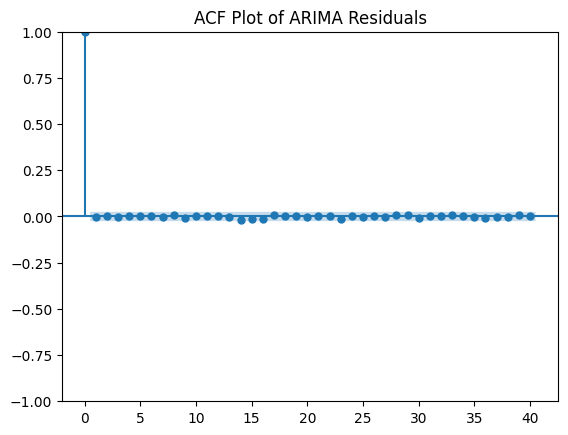

In [19]:
residuals = arima_result.resid

plt.figure(figsize=(14,4))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Distribution of ARIMA Residuals")
plt.xlabel("Residual")
plt.show()

plt.figure(figsize=(12,4))
plot_acf(residuals.dropna(), lags=40)
plt.title("ACF Plot of ARIMA Residuals")
plt.show()

## 14. ARIMA Forecasting

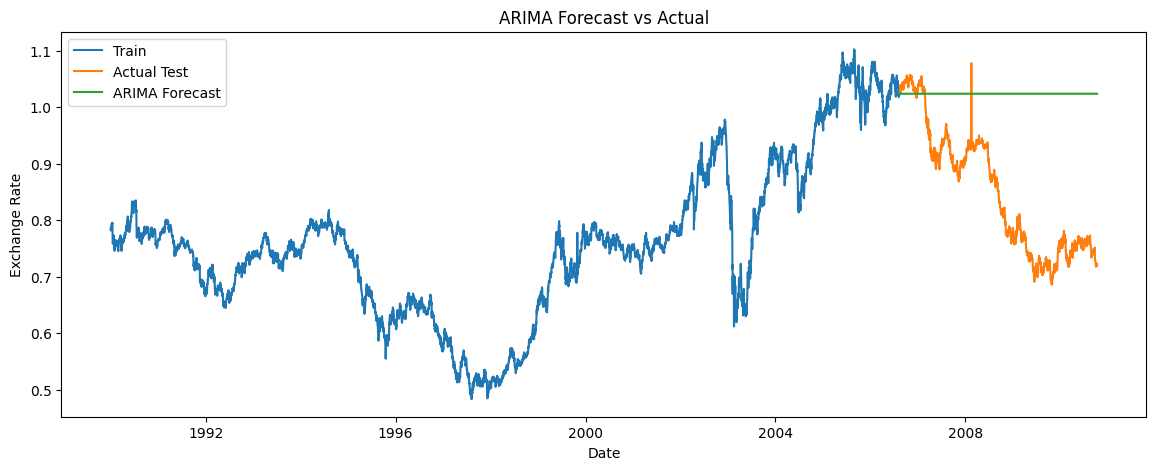

In [20]:
arima_forecast = arima_result.forecast(steps=len(test))
arima_forecast = pd.Series(arima_forecast.values, index=test.index)

plt.figure(figsize=(14,5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual Test")
plt.plot(arima_forecast, label="ARIMA Forecast")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

# Part 3: Model Building — Exponential Smoothing

## 15. Exponential Smoothing Model Selection

We try different Exponential Smoothing models:

1. Simple Exponential Smoothing  
2. Holt's Linear Trend Model  
3. Holt-Winters Exponential Smoothing  

The model with lower error is preferred.

In [21]:
# Simple Exponential Smoothing
ses_model = SimpleExpSmoothing(train).fit()
ses_forecast = ses_model.forecast(len(test))
ses_forecast = pd.Series(ses_forecast.values, index=test.index)

# Holt's Linear Trend
holt_model = Holt(train).fit()
holt_forecast = holt_model.forecast(len(test))
holt_forecast = pd.Series(holt_forecast.values, index=test.index)

# Holt-Winters Exponential Smoothing without seasonality
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None
).fit()

hw_forecast = hw_model.forecast(len(test))
hw_forecast = pd.Series(hw_forecast.values, index=test.index)

print("Exponential Smoothing models fitted successfully.")

Exponential Smoothing models fitted successfully.


## 16. Visual Comparison of Exponential Smoothing Forecasts

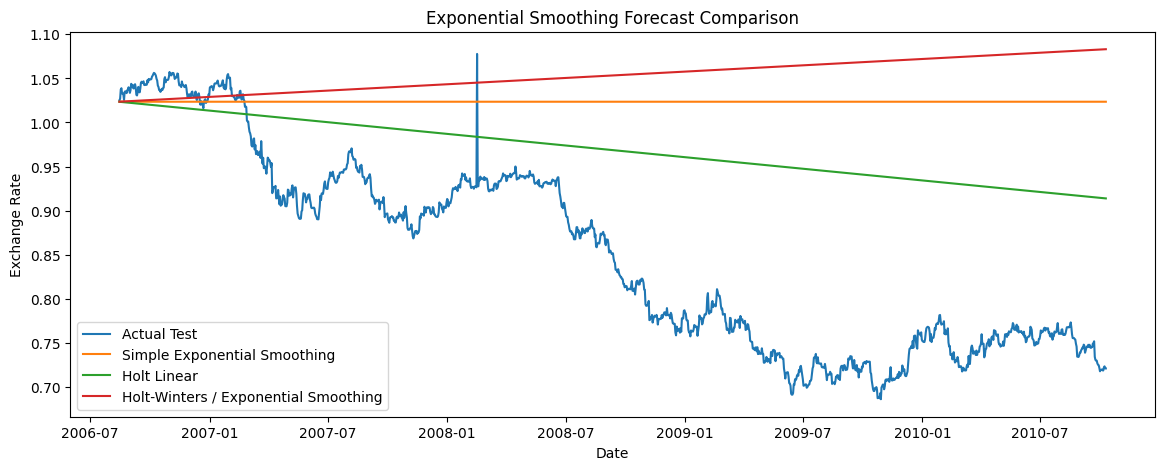

In [22]:
plt.figure(figsize=(14,5))
plt.plot(test, label="Actual Test")
plt.plot(ses_forecast, label="Simple Exponential Smoothing")
plt.plot(holt_forecast, label="Holt Linear")
plt.plot(hw_forecast, label="Holt-Winters / Exponential Smoothing")
plt.title("Exponential Smoothing Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

# Part 4: Evaluation and Comparison

## 17. Error Metrics

We calculate:

- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error
- MAPE: Mean Absolute Percentage Error

In [23]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_forecast(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(actual, predicted)

    print(f"Evaluation Metrics for {model_name}")
    print("-" * 45)
    print("MAE :", round(mae, 6))
    print("RMSE:", round(rmse, 6))
    print("MAPE:", round(mape, 4), "%")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

results = []

results.append(evaluate_forecast(test, arima_forecast, "ARIMA"))
results.append(evaluate_forecast(test, ses_forecast, "Simple Exponential Smoothing"))
results.append(evaluate_forecast(test, holt_forecast, "Holt Linear Trend"))
results.append(evaluate_forecast(test, hw_forecast, "Exponential Smoothing"))

Evaluation Metrics for ARIMA
---------------------------------------------
MAE : 0.177817
RMSE: 0.205557
MAPE: 22.8116 %
Evaluation Metrics for Simple Exponential Smoothing
---------------------------------------------
MAE : 0.177638
RMSE: 0.205356
MAPE: 22.7889 %
Evaluation Metrics for Holt Linear Trend
---------------------------------------------
MAE : 0.124573
RMSE: 0.144038
MAPE: 15.9642 %
Evaluation Metrics for Exponential Smoothing
---------------------------------------------
MAE : 0.206596
RMSE: 0.239104
MAPE: 26.5087 %


## 18. Model Comparison Table

,Model,MAE,RMSE,MAPE
2,Holt Linear Trend,0.124573,0.144038,15.964178
1,Simple Exponential Smoothing,0.177638,0.205356,22.788856
0,ARIMA,0.177817,0.205557,22.811638
3,Exponential Smoothing,0.206596,0.239104,26.508664


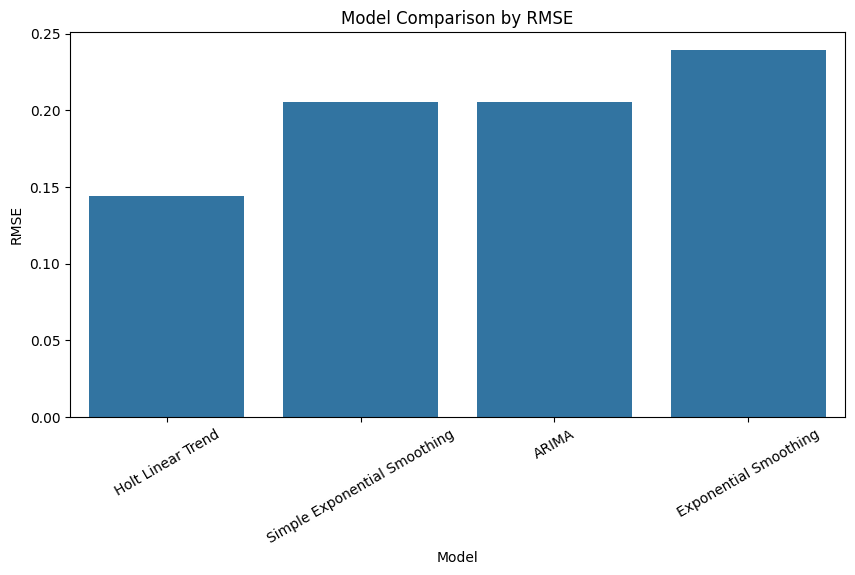

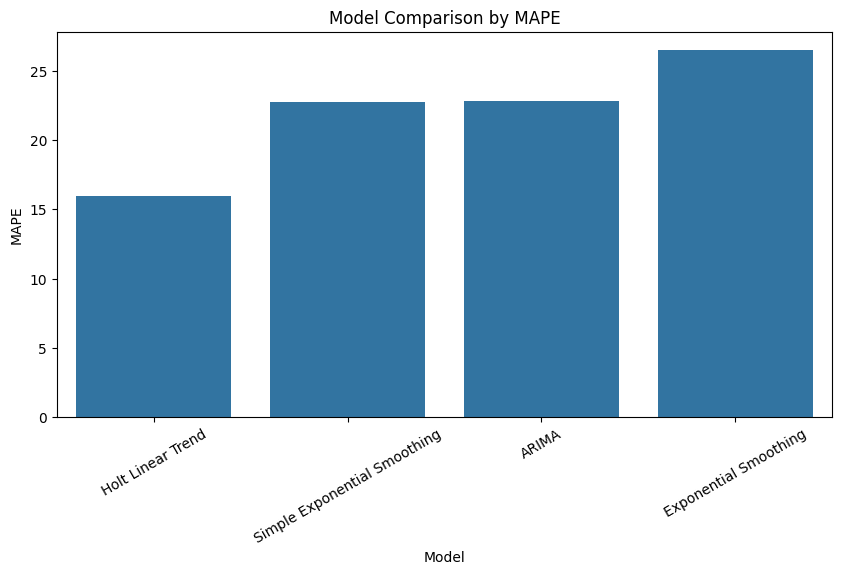

In [24]:
results_df = pd.DataFrame(results).sort_values(by="RMSE")
display(results_df)

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="MAPE")
plt.title("Model Comparison by MAPE")
plt.xticks(rotation=30)
plt.show()

## 19. Final Forecast Comparison Plot

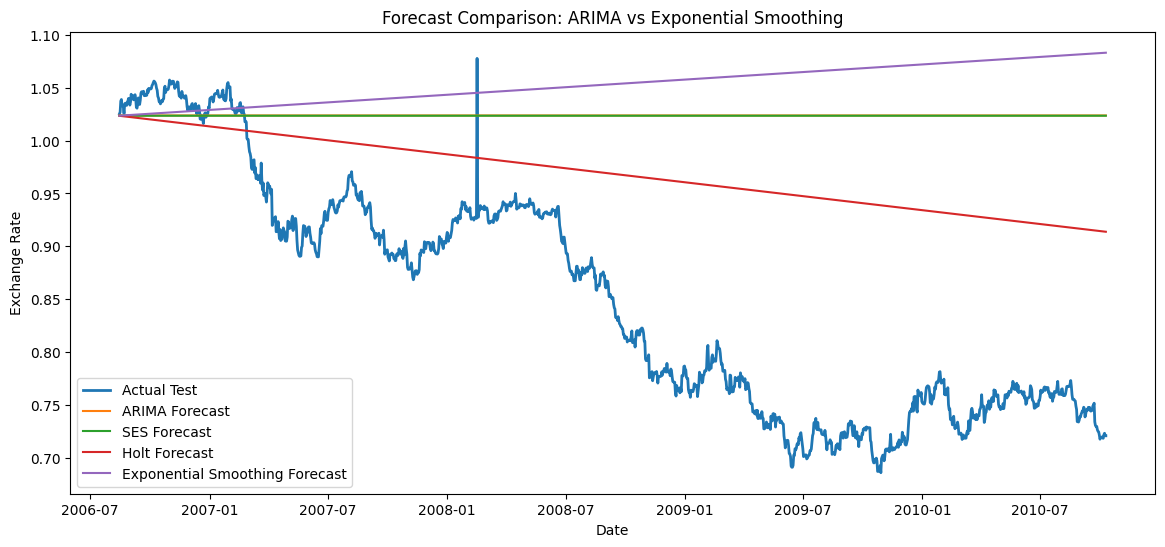

In [25]:
plt.figure(figsize=(14,6))
plt.plot(test, label="Actual Test", linewidth=2)
plt.plot(arima_forecast, label="ARIMA Forecast")
plt.plot(ses_forecast, label="SES Forecast")
plt.plot(holt_forecast, label="Holt Forecast")
plt.plot(hw_forecast, label="Exponential Smoothing Forecast")
plt.title("Forecast Comparison: ARIMA vs Exponential Smoothing")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

## 20. Forecast Future Exchange Rates

Now we forecast future values using the best model based on RMSE.

Best Model Based on RMSE: Holt Linear Trend


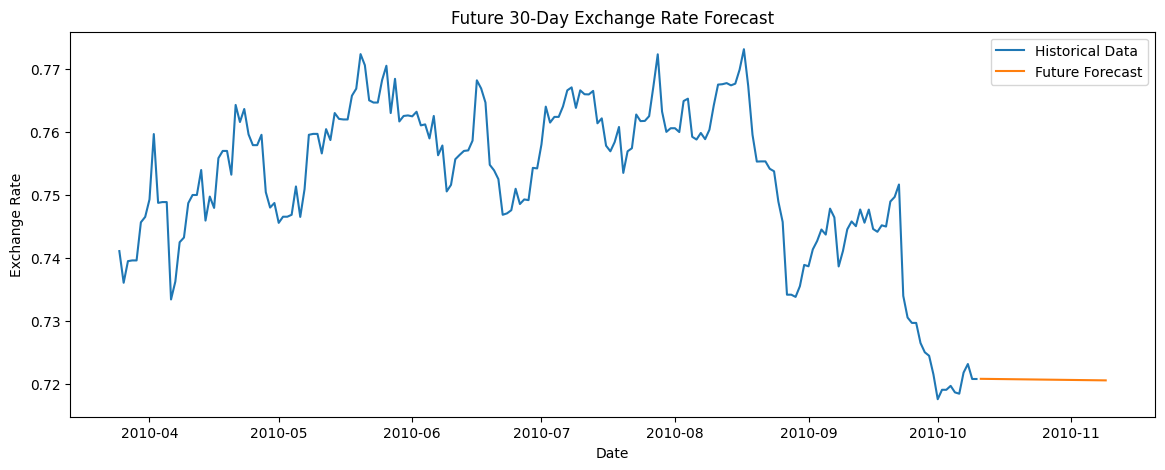

2010-10-11    0.720852
2010-10-12    0.720843
2010-10-13    0.720835
2010-10-14    0.720826
2010-10-15    0.720818
Freq: D, dtype: float64

In [26]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model Based on RMSE:", best_model_name)

future_steps = 30

if best_model_name == "ARIMA":
    final_model = ARIMA(series, order=best_order).fit()
    future_forecast = final_model.forecast(steps=future_steps)
else:
    final_model = ExponentialSmoothing(series, trend="add", seasonal=None).fit()
    future_forecast = final_model.forecast(future_steps)

future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq="D"
)

future_forecast = pd.Series(future_forecast.values, index=future_dates)

plt.figure(figsize=(14,5))
plt.plot(series.tail(200), label="Historical Data")
plt.plot(future_forecast, label="Future Forecast")
plt.title("Future 30-Day Exchange Rate Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

display(future_forecast.head())

## 21. Model Comparison Discussion

### ARIMA

Advantages:
1. Good for time series data with trend and autocorrelation.
2. Uses past values and past errors for forecasting.
3. ACF and PACF help in selecting parameters.

Limitations:
1. Requires stationarity or differencing.
2. Parameter selection can be time-consuming.
3. May not perform well if complex seasonality is present.

### Exponential Smoothing

Advantages:
1. Simple and easy to implement.
2. Works well for data with level and trend.
3. Gives more weight to recent observations.

Limitations:
1. May not capture complex autocorrelation as ARIMA does.
2. Requires selecting proper trend and seasonality components.
3. Forecast accuracy depends on smoothing parameters.

### Based on Error Metrics

The model with the lowest RMSE and MAPE is considered better for this dataset.

## 22. Final Conclusion

In this assignment, exchange rate forecasting was performed using ARIMA and Exponential Smoothing techniques.

The dataset was loaded, the date column was parsed properly, and the exchange rate time series was visualized to understand trend and variation. Missing values and duplicate dates were checked and handled.

For ARIMA, stationarity was checked using the ADF test. First differencing was applied when required. ACF and PACF plots were used to understand possible parameter values, and AIC-based search was used to select the best ARIMA order. The ARIMA model was fitted, residuals were analyzed, and forecasts were generated.

For Exponential Smoothing, Simple Exponential Smoothing, Holt's Linear Trend, and Exponential Smoothing models were applied. Forecasts were compared visually with the actual test values.

The models were evaluated using MAE, RMSE, and MAPE. The best model was selected based on the lowest error metrics. This analysis shows how time series forecasting techniques can be used to predict future exchange rates and compare model performance.